# Tratamento da Unidade Movel Copacabana

Este notebook organiza o tratamento horário da Unidade Móvel `Copacabana` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da Unidade Móvel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade Móvel para evitar problemas de codificação e isolamos apenas os registros da Unidade Móvel `Copacabana`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_m_copacabana = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL COPACABANA"].copy()

df_m_copacabana["data"] = pd.to_datetime(df_m_copacabana["data"])
df_m_copacabana = df_m_copacabana.sort_values("data").reset_index(drop=True)
df_m_copacabana = df_m_copacabana.drop_duplicates(subset="data", keep="first")
df_m_copacabana = df_m_copacabana.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade Movel Copacabana:", df_m_copacabana.shape)
display(df_m_copacabana.head())

Dimensoes da base da Unidade Movel Copacabana: (2786, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2016-08-02 17:30:00,UNIDADE MOVEL COPACABANA,0.0,22.90,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,-22.976488,-43.193708
2016-08-02 18:30:00,UNIDADE MOVEL COPACABANA,0.0,23.35,74.82,3.47,NaN,NaN,NaN,NaN,11.59,NaN,25.0,-22.976488,-43.193708
2016-08-02 19:30:00,UNIDADE MOVEL COPACABANA,0.0,23.05,75.03,3.83,NaN,0.38,NaN,NaN,8.67,NaN,10.0,-22.976488,-43.193708
2016-08-02 20:30:00,UNIDADE MOVEL COPACABANA,0.0,22.88,73.28,4.58,NaN,0.22,NaN,NaN,13.27,NaN,11.0,-22.976488,-43.193708
2016-08-02 21:30:00,UNIDADE MOVEL COPACABANA,0.0,22.35,76.88,4.93,NaN,0.09,NaN,NaN,23.34,NaN,8.0,-22.976488,-43.193708


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_m_copacabana, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,2786,100.00,0
no2,2786,100.00,0
nox,2786,100.00,0
pm10,2786,100.00,0
so2,1037,37.22,1749
co,178,6.39,2608
pm2_5,74,2.66,2712
o3,67,2.40,2719
temp,58,2.08,2728
ur,47,1.69,2739


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_m_copacabana_tratado = df_m_copacabana.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_m_copacabana[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_m_copacabana_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_m_copacabana_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
8,co,interpolate_time,178,42,136
2,so2,interpolate_time,1037,907,130
3,pm2_5,interpolate_time,74,41,33
7,o3,interpolate_time,67,42,25
6,temp,interpolate_time,58,41,17
5,ur,interpolate_time,47,41,6
0,no,interpolate_time,2786,2786,0
1,no2,interpolate_time,2786,2786,0
4,nox,interpolate_time,2786,2786,0
9,pm10,interpolate_time,2786,2786,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 347


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
co,178,6.39,42,1.51,136,76.40
so2,1037,37.22,907,32.56,130,12.54
pm2_5,74,2.66,41,1.47,33,44.59
o3,67,2.40,42,1.51,25,37.31
temp,58,2.08,41,1.47,17,29.31
ur,47,1.69,41,1.47,6,12.77
no,2786,100.00,2786,100.00,0,0.00
nox,2786,100.00,2786,100.00,0,0.00
no2,2786,100.00,2786,100.00,0,0.00
pm10,2786,100.00,2786,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,1.984282,1.01,2.807028,1.968361,1.000,2.775338,-0.015922,-0.031689
pm2_5,8.487832,6.00,9.265095,8.492350,6.000,9.265167,0.004518,0.000073
ur,71.398185,72.12,11.991898,71.381827,72.100,11.987430,-0.016359,-0.004468
temp,23.301034,23.10,2.637559,23.305375,23.100,2.635628,0.004342,-0.001931
o3,22.002865,19.32,16.948011,22.078023,19.475,16.947371,0.075158,-0.000641
co,0.309145,0.23,0.307641,0.309191,0.230,0.305824,0.000046,-0.001817
chuva,0.065646,0.00,0.459281,0.065646,0.000,0.459281,0.000000,0.000000


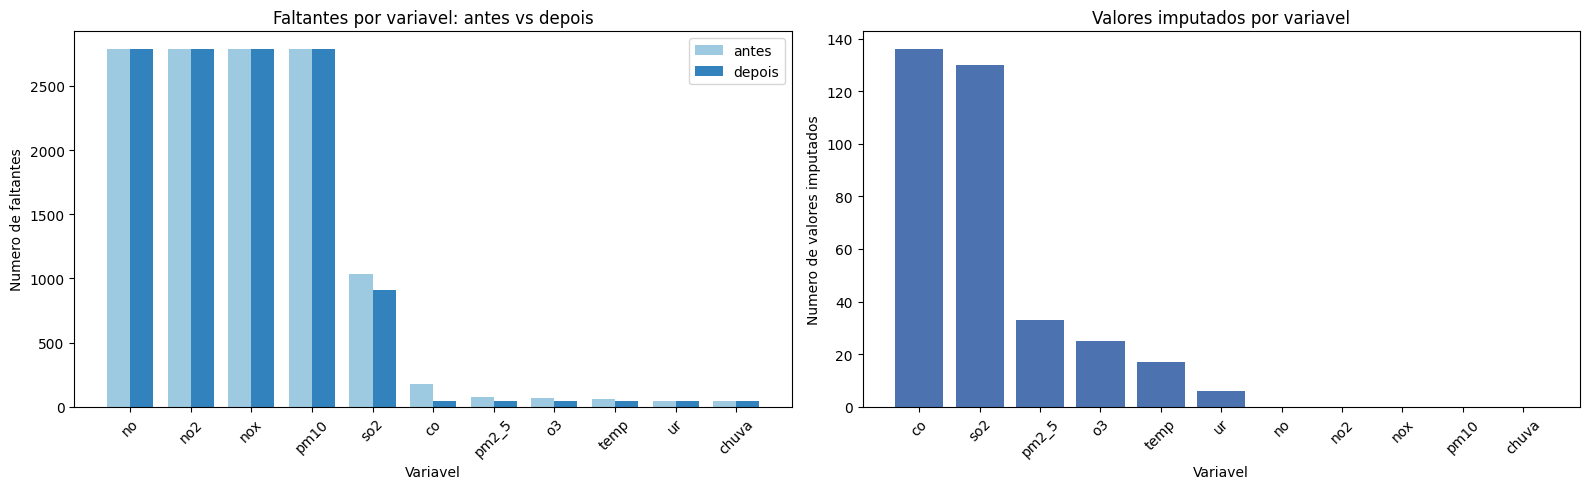

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_m_copacabana_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_m_copacabana[variavel].notna().any() or df_m_copacabana_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_m_copacabana, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_m_copacabana_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a Unidade Movel `Copacabana`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_um_copacabana_diario = (
    df_m_copacabana_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

df_um_copacabana_diario_saida = df_um_copacabana_diario.reset_index()
output_csv_diario_path = output_dir / "um_copacabana_tratado_diario.csv"
df_um_copacabana_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_um_copacabana_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_copacabana_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2016-08-02,NaN,NaN,4.267500,12.333333,NaN,73.768333,22.811429,16.903333,0.209286,NaN,0.0
1,2016-08-03,NaN,NaN,2.669792,9.208333,NaN,67.096250,22.485833,16.751250,0.324167,NaN,0.0
2,2016-08-04,NaN,NaN,2.018333,6.541667,NaN,63.971667,22.478750,14.466250,0.418542,NaN,0.0
3,2016-08-05,NaN,NaN,2.782083,7.833333,NaN,66.429583,22.500417,16.942083,0.498958,NaN,0.0
4,2016-08-06,NaN,NaN,12.102083,23.958333,NaN,50.864583,26.195417,8.363333,1.007083,NaN,0.0


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Copacabana` manteve a estratégia conservadora de interpolação temporal em lacunas curtas (até `4` horas). Foram imputados `347` valores no total, com maior contribuição em `co` (`136`), `so2` (`130`), `pm2_5` (`33`) e `o3` (`25`). Os ganhos em `temp` e `ur` foram menores (`17` e `6`), e `chuva` ficou sem imputação.

A maior melhora de completude ocorreu em `co` (`6,39%` para `1,51%` de missing). Também houve redução em `pm2_5` (`2,66%` para `1,47%`), `o3` (`2,40%` para `1,51%`), `temp` (`2,08%` para `1,47%`) e `ur` (`1,69%` para `1,47%`). Em `so2`, apesar da redução (`37,22%` para `32,56%`), o percentual de faltantes permaneceu alto, indicando lacunas extensas na campanha.

Assim como nas demais unidades móveis, `no`, `no2`, `nox` e `pm10` seguiram com `100%` de missing, apontando ausência estrutural desses poluentes na base. A comparação estatística antes e depois mostra variações pequenas nas medidas centrais das variáveis observadas, indicando ganho de completude sem alteração relevante da distribuição das séries.